In [1]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

In [43]:
data=pd.read_excel("clean_data_Density.xlsx")
data = data.replace({',': '.'}, regex=True)
data.columns=['p','v','h','t','density','ved']
Df=data[['p','v','h','t','density']]


In [2]:
data=pd.read_excel("data - copie.xlsx")
data = data.replace({',': '.'}, regex=True)
data.columns=['p','v','h','t','Ra','Desnity','VED','LED','PED']
Df=data[['p','v','h','t','Ra']]

In [12]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(Df)

lowest_bic = np.infty
lowest_aic = np.infty
bic_scores = []
aic_scores = []
n_components_range = range(1, 20)  
models = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=0)
    gmm.fit(data_scaled)
    models.append(gmm)
    
    bic = gmm.bic(data_scaled)
    aic = gmm.aic(data_scaled)
    
    bic_scores.append(bic)
    aic_scores.append(aic)

    if bic < lowest_bic:
        best_gmm_bic = gmm
        lowest_bic = bic
    if aic < lowest_aic:
        best_gmm_aic = gmm
        lowest_aic = aic


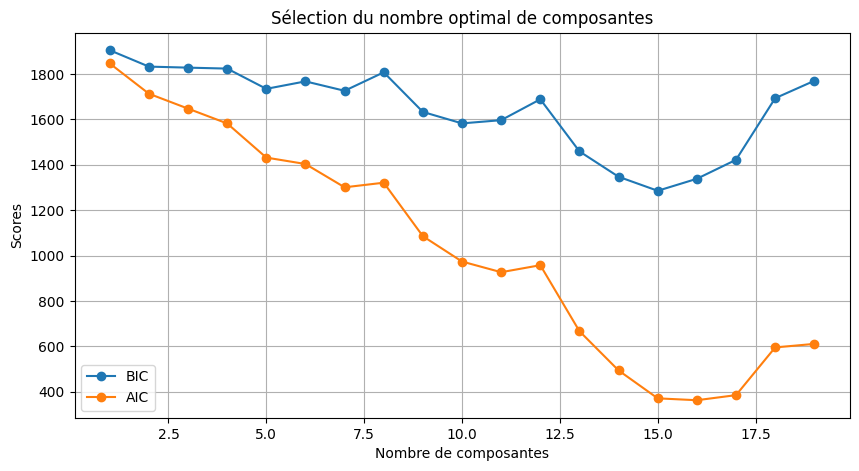

In [13]:

plt.figure(figsize=(10, 5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.plot(n_components_range, aic_scores, label='AIC', marker='o')
plt.xlabel('Nombre de composantes')
plt.ylabel('Scores')
plt.title('Sélection du nombre optimal de composantes')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
best_gmm = GaussianMixture(n_components=18, covariance_type='full', random_state=0)
best_gmm.fit(data_scaled)


GaussianMixture(n_components=18, random_state=0)

In [10]:
synthetic_scaled, _ = best_gmm.sample(1400)  
synthetic_data = scaler.inverse_transform(synthetic_scaled)
synthetic_df = pd.DataFrame(synthetic_data, columns=Df.columns)


In [11]:

print("🔹 Données réelles :")
print(Df.describe())

print("\n🔹 Données synthétiques :")
print(synthetic_df.describe())


🔹 Données réelles :
                p            v           h           t          Ra
count  136.000000   136.000000  136.000000  136.000000  136.000000
mean   187.919118   759.191176   95.970588   34.154412    9.952868
std     83.143846   247.760690   27.721178   12.642596    5.129858
min     60.000000   250.000000   50.000000   20.000000    2.600000
25%    150.000000   600.000000   80.000000   25.000000    6.285000
50%    160.000000   760.000000   90.000000   30.000000    9.580000
75%    225.000000   900.000000  115.000000   40.000000   11.540000
max    370.000000  1300.000000  200.000000   60.000000   31.310000

🔹 Données synthétiques :
                 p            v            h            t           Ra
count  1400.000000  1400.000000  1400.000000  1400.000000  1400.000000
mean    187.563069   759.658588    97.058326    34.639165    10.043898
std      83.698993   248.324808    29.298760    12.847742     5.316507
min      27.979702    44.727246    26.080800    15.175899    -0.251

In [130]:
synthetic_df.shape

(1400, 5)

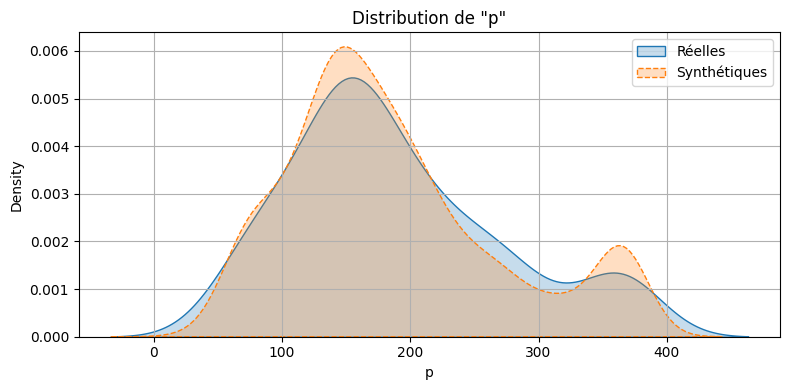

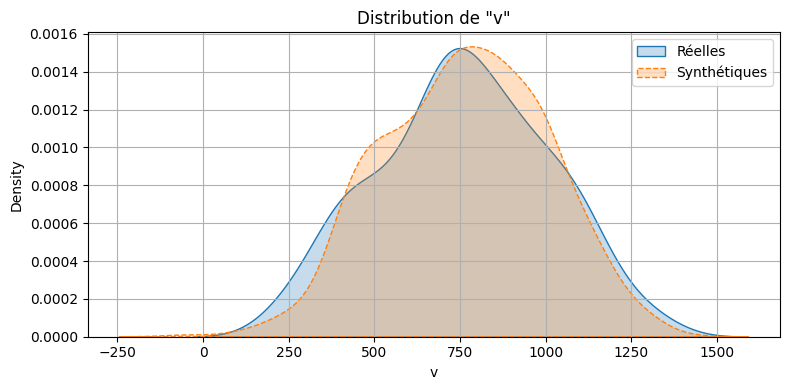

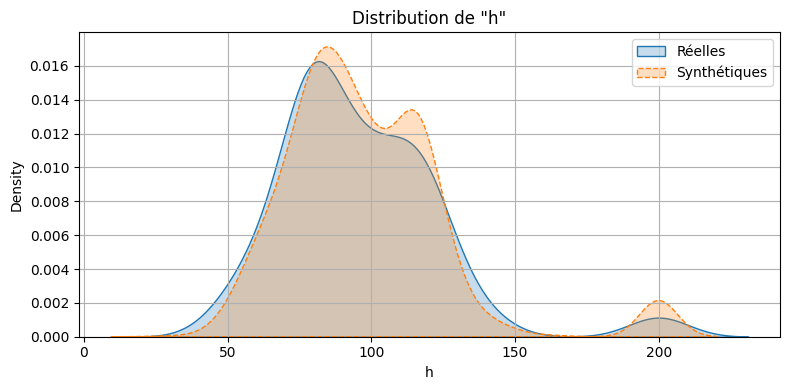

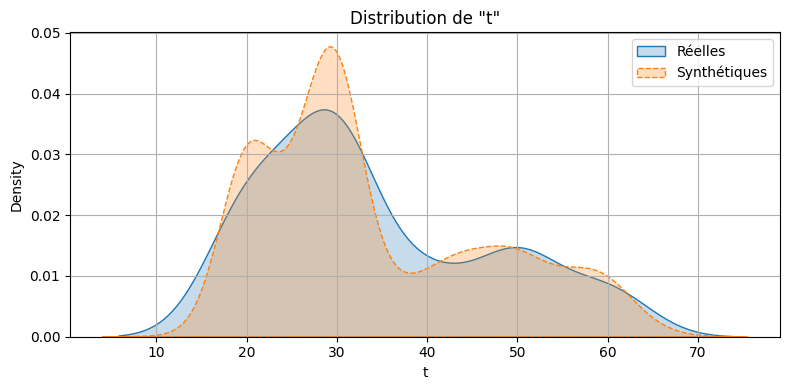

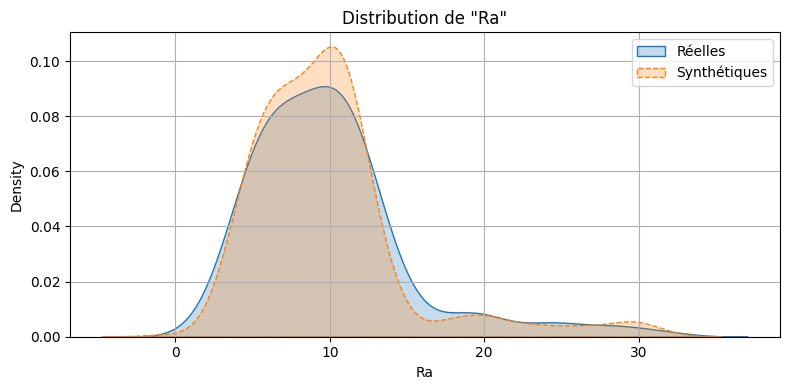

In [8]:

for column in Df.columns:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(Df[column], label='Réelles', fill=True)
    sns.kdeplot(synthetic_df[column], label='Synthétiques', fill=True, linestyle='--')
    plt.title(f'Distribution de "{column}"')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [39]:
def box_cox_fun(data, lambda_val=0.5):
    return ((data + 1e-5) ** lambda_val - 1) / lambda_val

def inverse_box_cox(data, lambda_val=0.5):
    if lambda_val == 0:
        return np.exp(data)
    else:
        return (data * lambda_val + 1) ** (1 / lambda_val) - 1e-5

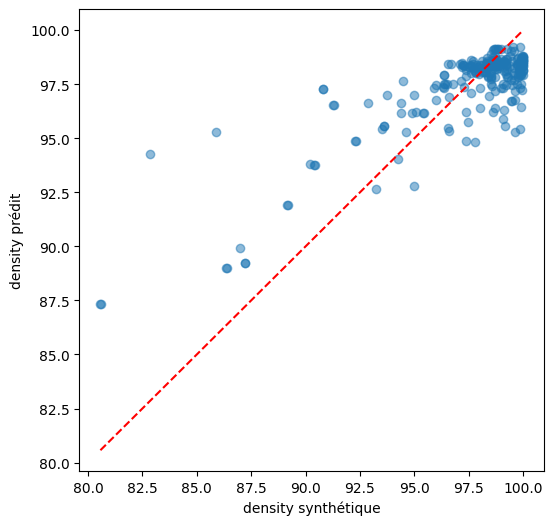

RMSE = 2.0026 | R² = 0.6374


In [118]:

X_real = Df[['p','v','h','t']]
y_real = Df['density']
scaler = MinMaxScaler()
X_real_scaled = scaler.fit_transform(X_real)
scaler_y=MinMaxScaler()
y_synth_bc = scaler_y.fit_transform(synthetic_df['density'].values.reshape(-1, 1))

model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.001,
    depth=10,
    loss_function='RMSE',
    verbose=0,
   
)
X_synth = synthetic_df[['p','v','h','t']]
X_synth_scaled=scaler.fit_transform(X_synth)

model.fit(X_synth_scaled, y_synth_bc)



y_pred_bc = model.predict(X_real_scaled)
y_pred=scaler_y.inverse_transform(y_pred_bc.reshape(-1,1))


plt.figure(figsize=(6,6))
plt.scatter(y_real, y_pred, alpha=0.5)
plt.plot([y_real.min(), y_real.max()], 
         [y_real.min(), y_real.max()], 'r--')
plt.xlabel('density synthétique')
plt.ylabel('density prédit')

plt.show()


mse = mean_squared_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)
print(f"RMSE = {np.sqrt(mse):.4f} | R² = {r2:.4f}")

c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       901
           1       0.00      0.00      0.00        49

    accuracy                           0.95       950
   macro avg       0.47      0.50      0.49       950
weighted avg       0.90      0.95      0.92       950



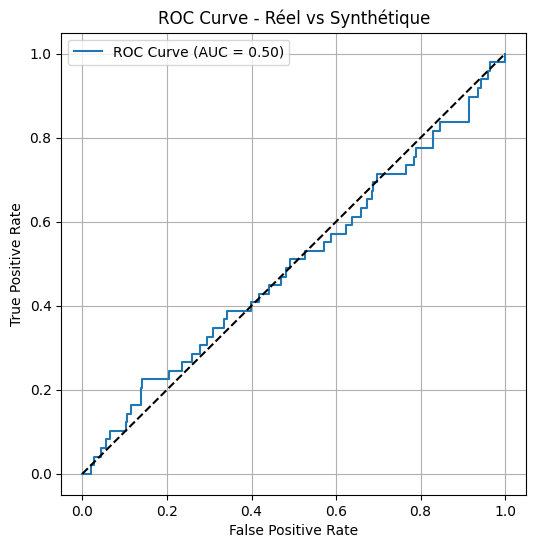

In [119]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve


from sklearn.linear_model import LogisticRegression
real_with_label = X_real.copy()
real_with_label['label'] = 1

synth_with_label = X_synth.copy()
synth_with_label['label'] = 0


df_disc = pd.concat([real_with_label, synth_with_label], ignore_index=True)

X_disc = df_disc.drop(columns=['label'])
y_disc = df_disc['label']

X_train_disc, X_test_disc, y_train_disc, y_test_disc = train_test_split(X_disc, y_disc, stratify=y_disc, test_size=0.2, random_state=42,shuffle=True)



clf = LogisticRegression()
clf.fit(X_train_disc, y_train_disc)

y_pred_disc = clf.predict(X_test_disc)
y_proba_disc = clf.predict_proba(X_test_disc)[:, 1]


print("Classification Report:\n", classification_report(y_test_disc, y_pred_disc))


auc = roc_auc_score(y_test_disc, y_proba_disc)
fpr, tpr, _ = roc_curve(y_test_disc, y_proba_disc)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Réel vs Synthétique')
plt.legend()
plt.grid()
plt.show()


In [121]:

df_synthetic = synthetic_df.copy()
df_synthetic['density'] = synthetic_df['density']
df_synthetic.to_excel('synthetic_data_gmm_density.xlsx', index=False)